# 02 — RQ1 single-node query performance

Bytes transferred, wall-clock time (minimum estimator), four-term operational cost, CPU decomposition. Workloads point-in-polygon / kNN / bbox at small + large; Shapefile (`local`) is small-only (cells absent by design render as `did not run`).

**Storage-footprint table (`tab:appendix-storage-footprint`) is FLAGGED, not produced** — the cache has no on-disk byte-size metric (only a prorated `storage_cost` in USD), so it cannot be populated without fabricating sizes.

In [1]:
import os
from pathlib import Path
if Path.cwd().name == "notebooks":
    os.chdir("..")
from src.plotting.style import StyleConfig
from src.analysis.tables import build_cost_summary
from src.analysis import thesis_compute as tc
from src.plotting import thesis_figures as tf

style = StyleConfig(); style.apply_rcparams()
CACHE = os.environ.get("DOPPA_CACHE", "cache/bench-cache.duckdb")
RUN_ID = "2026-05-26-OY0CN3"
FIG = Path("figures")
RQ1_W = ["point-in-polygon-lookup", "knn-search", "bbox-filtering"]
RQ1_C = ["duckdb", "postgis", "local"]
TIERS = ["small", "large"]

experiments, samples_df, metadata_df, costs_df, successful = tc.load_all(
    CACHE, "../doppa/benchmarks.yml", RUN_ID)
cost_summary = build_cost_summary(costs_df)
rq1_cost = cost_summary[cost_summary.index.get_level_values("workload_type").isin(RQ1_W)]
print("successful samples:", successful.shape)

successful samples: (394834, 26)


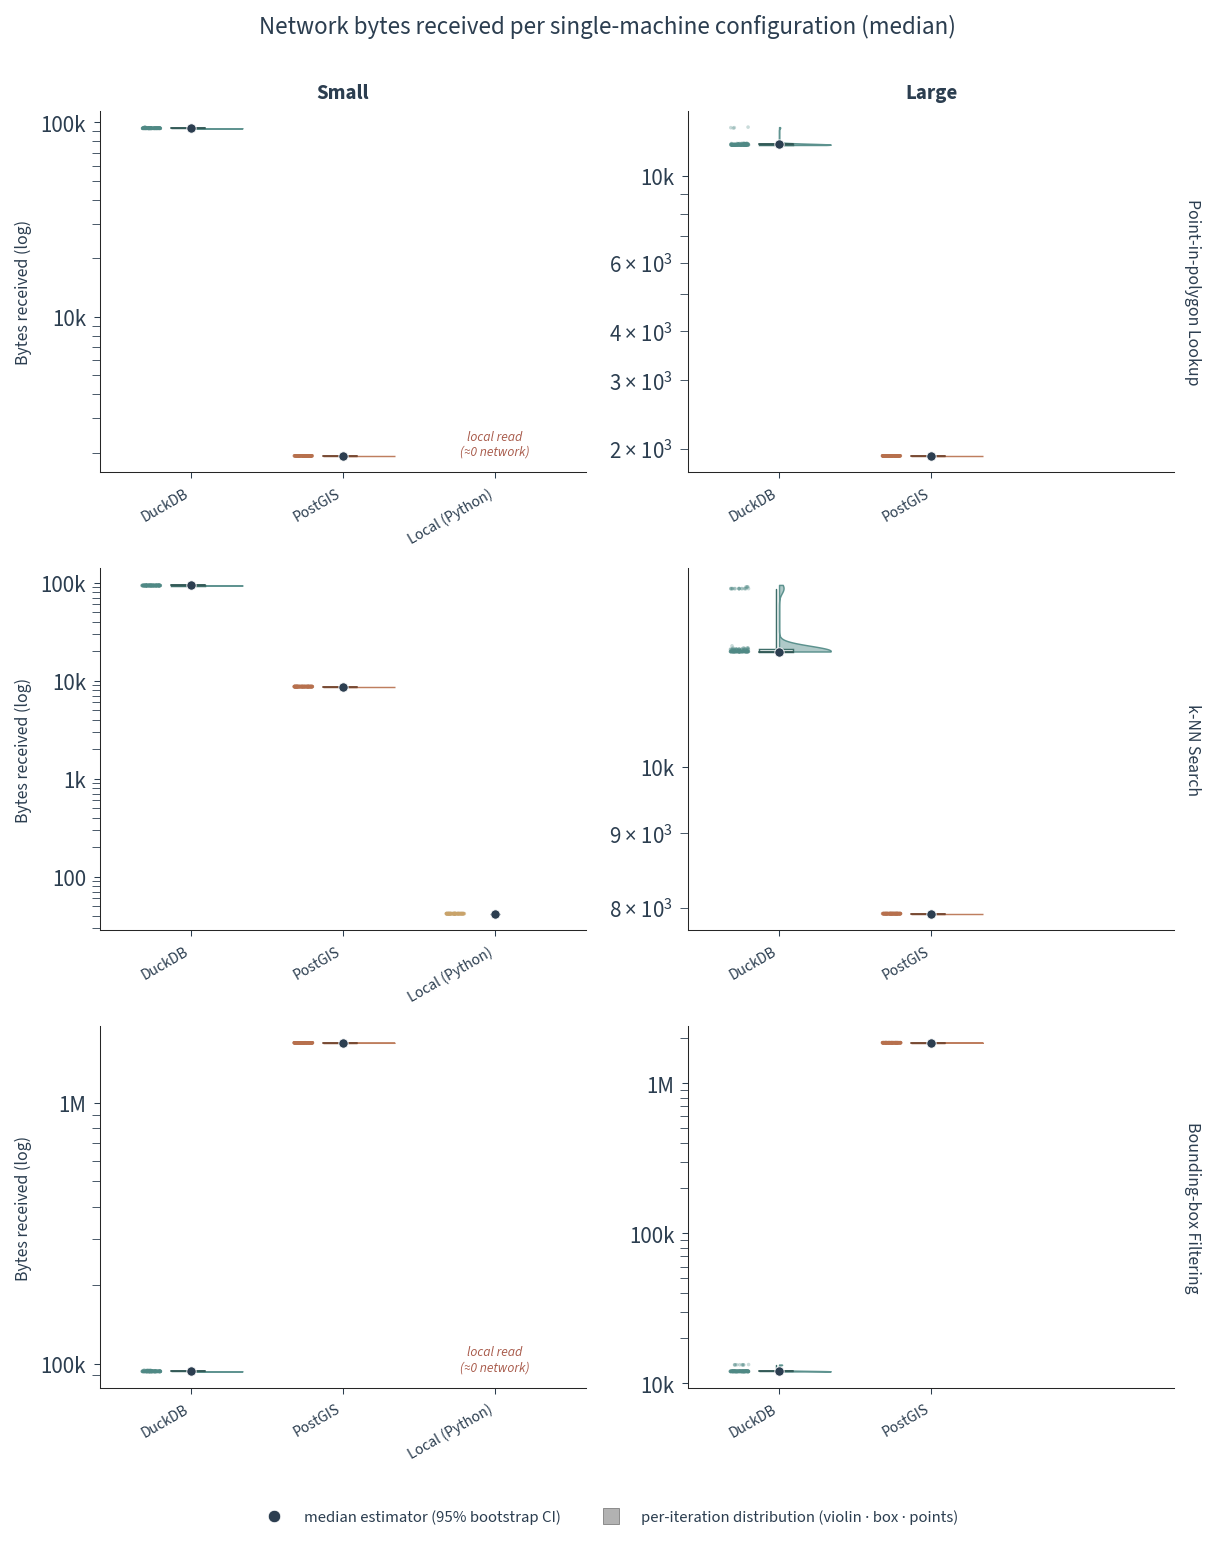

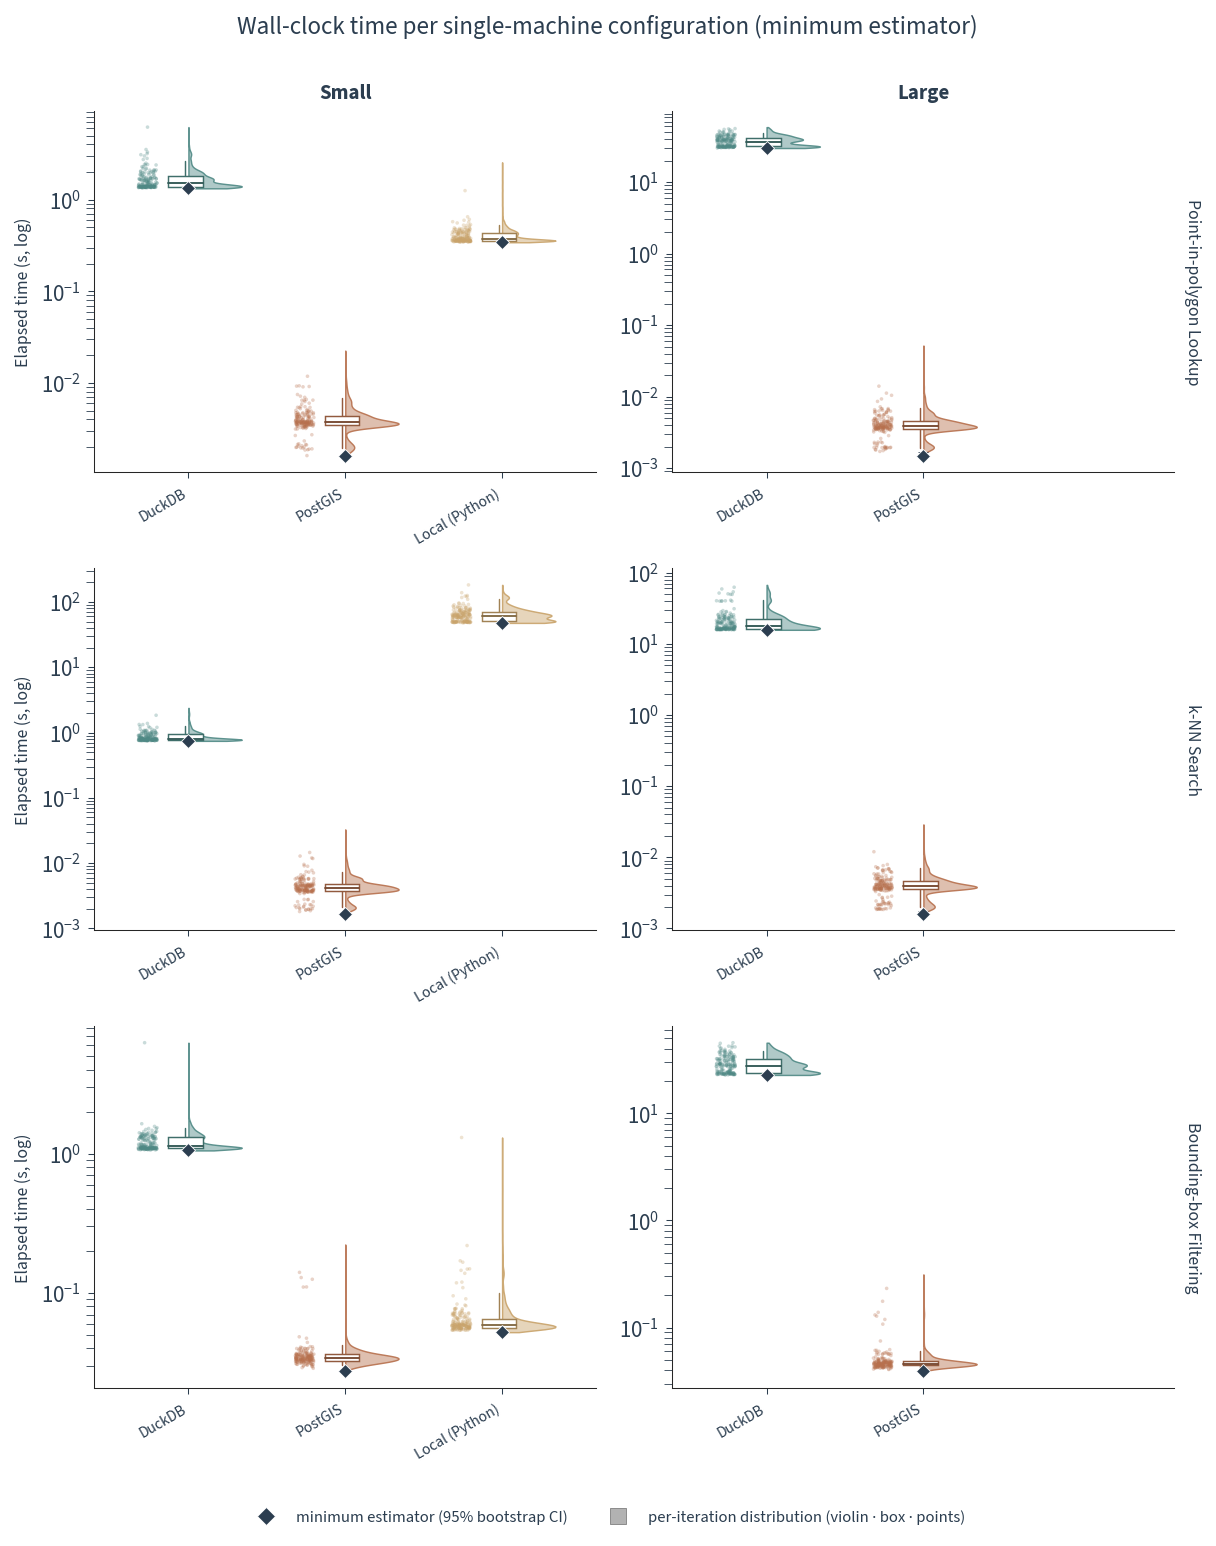

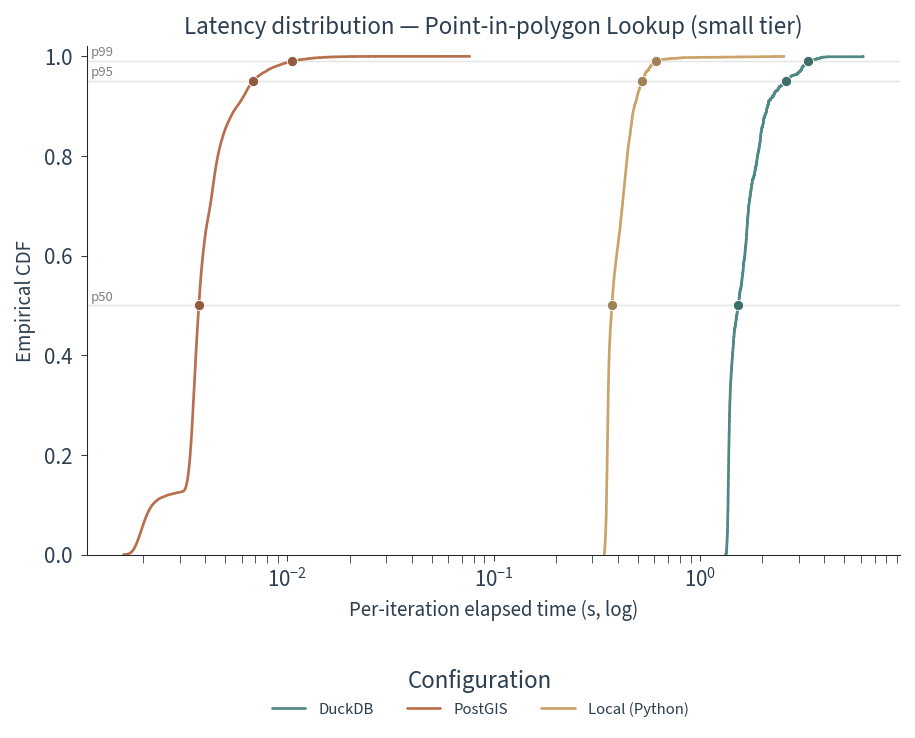

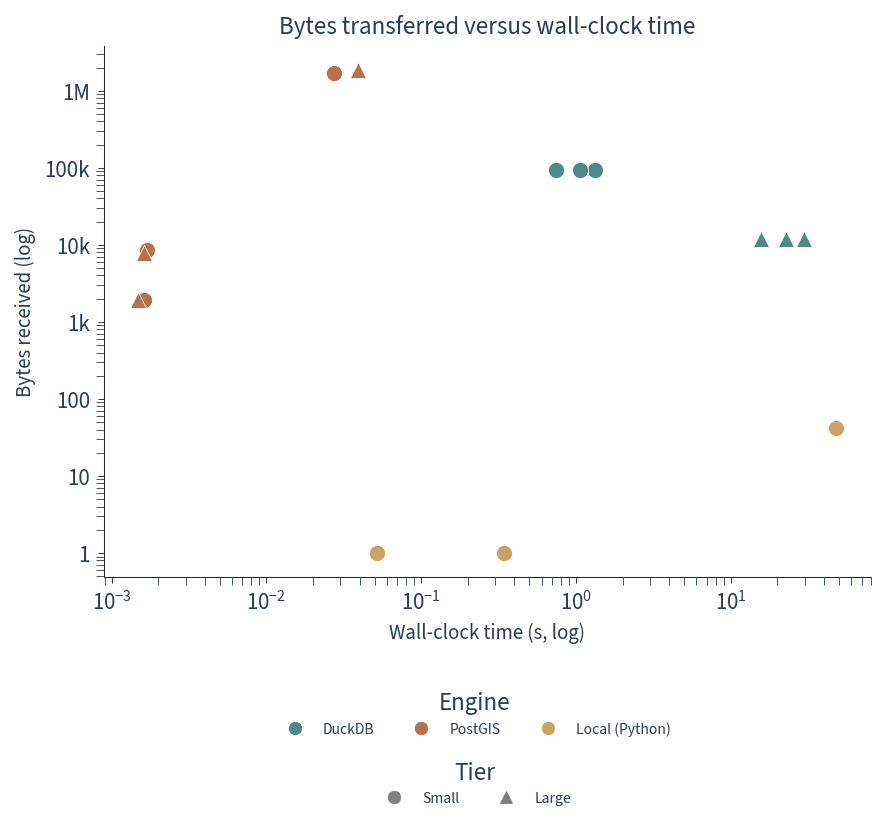

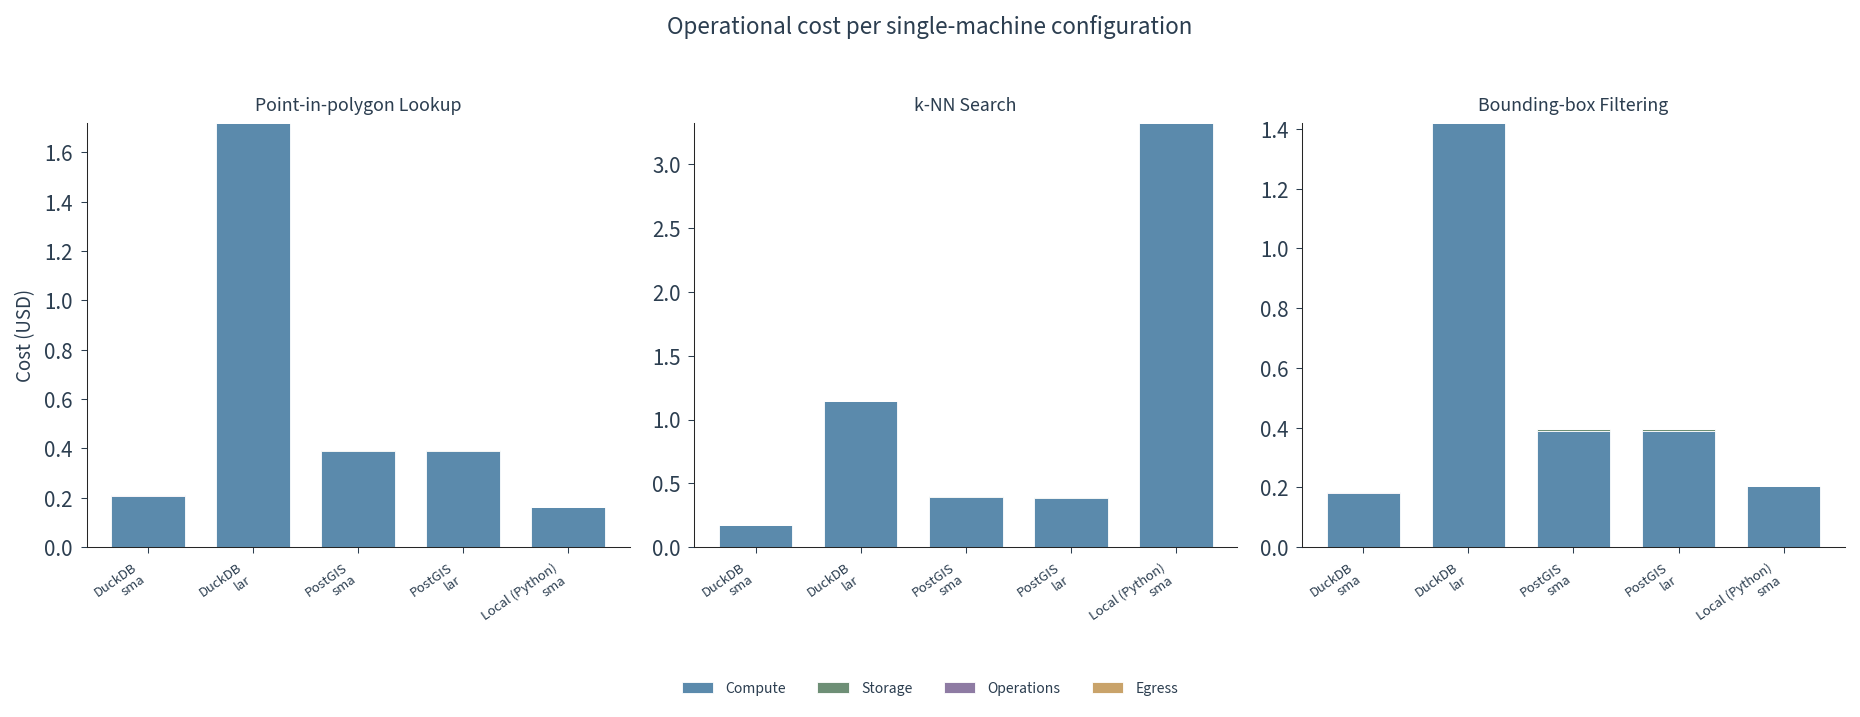

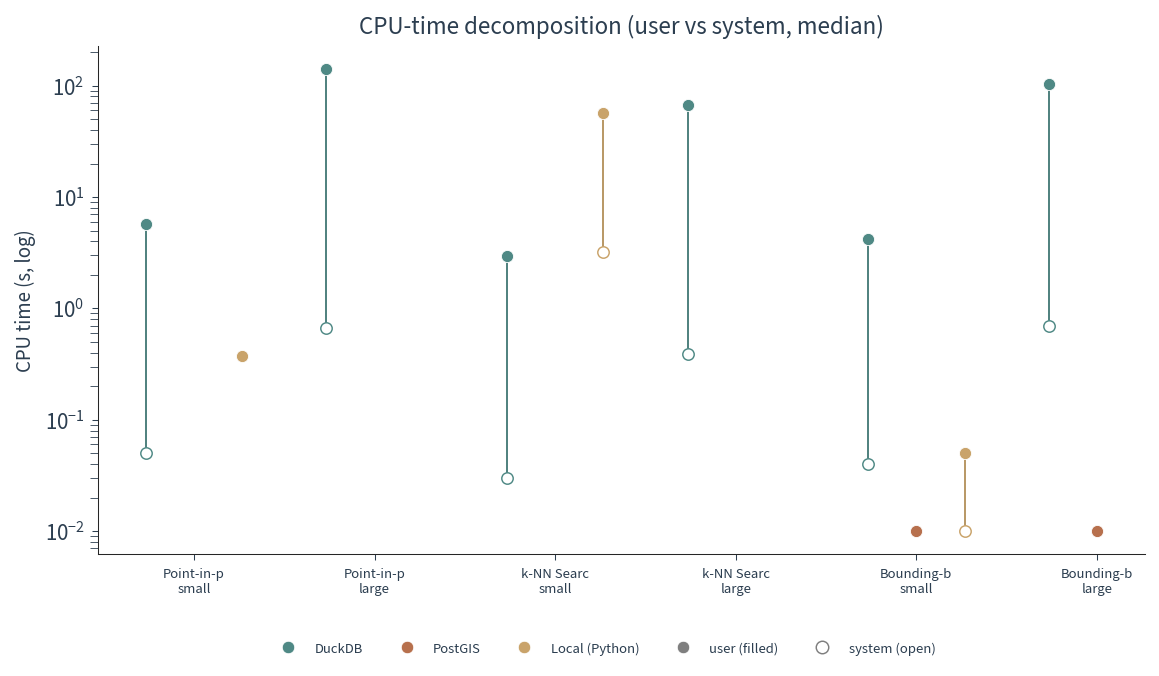

PosixPath('figures/09-cpu-decomposition.png')

In [2]:
tf.fig_rq1_bytes_grid(successful, RQ1_W, RQ1_C, TIERS, style, FIG / "06-single-machine-bytes-transferred.png")
tf.fig_rq1_time_grid(successful, RQ1_W, RQ1_C, TIERS, style, FIG / "06-single-machine-wall-clock-time.png")
tf.fig_rq1_latency_ecdf(successful, "point-in-polygon-lookup", "small", RQ1_C, style, FIG / "06-single-machine-latency-ecdf.png")
tf.fig_rq1_bytes_vs_time(successful, RQ1_W, RQ1_C, TIERS, style, FIG / "06-single-machine-bytes-vs-time.png")
tf.fig_rq1_operational_cost(rq1_cost, RQ1_W, RQ1_C, TIERS, style, FIG / "06-single-machine-operational-cost.png")
tf.fig_cpu_decomposition(successful, RQ1_W, RQ1_C, TIERS, style, FIG / "09-cpu-decomposition.png")

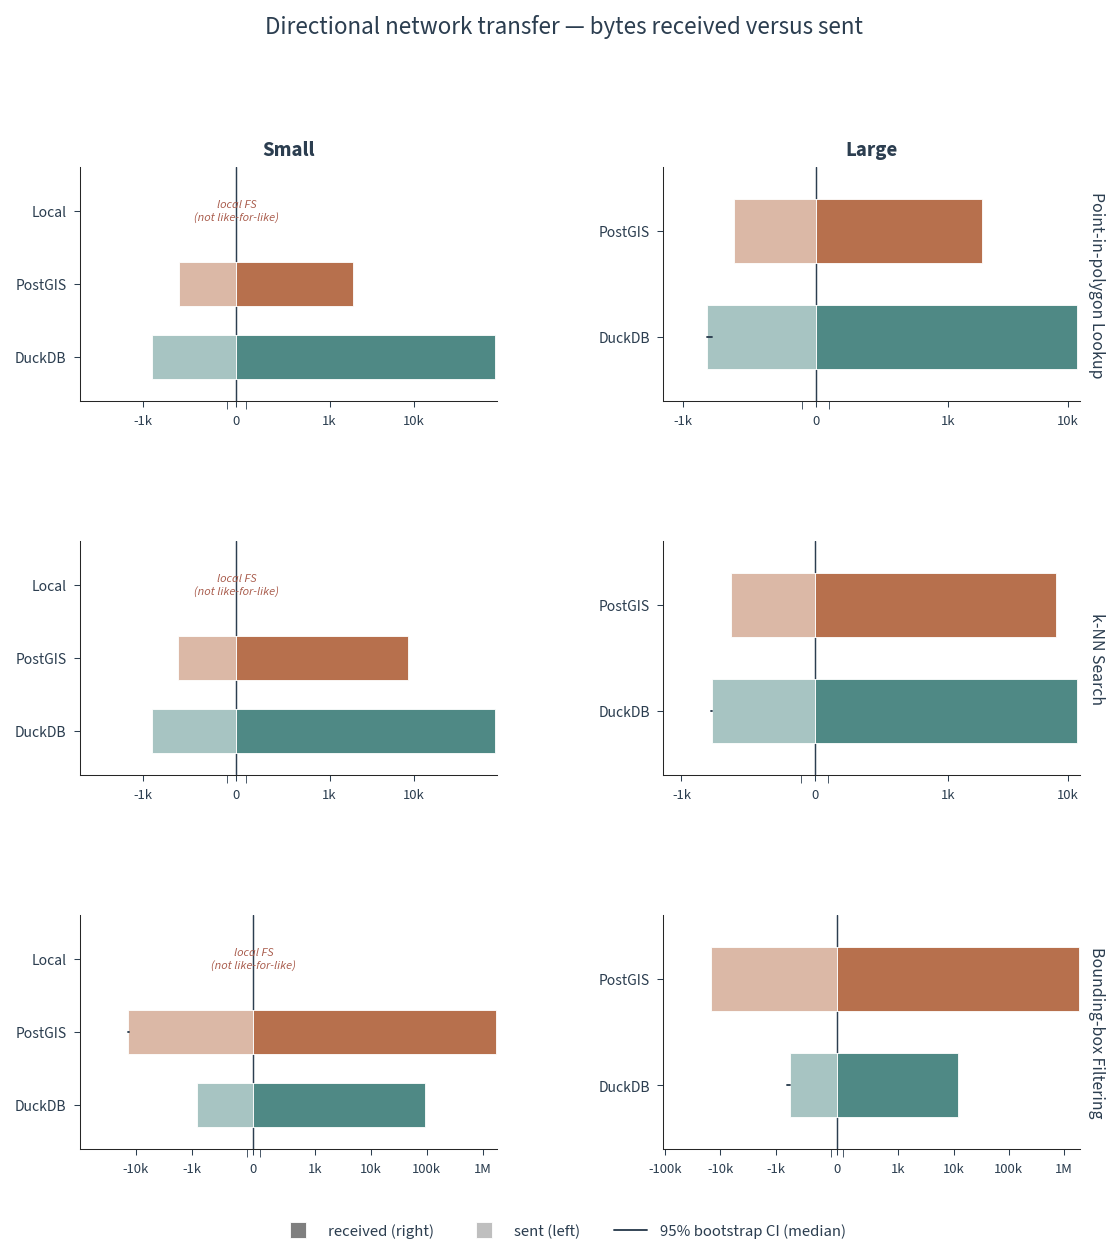

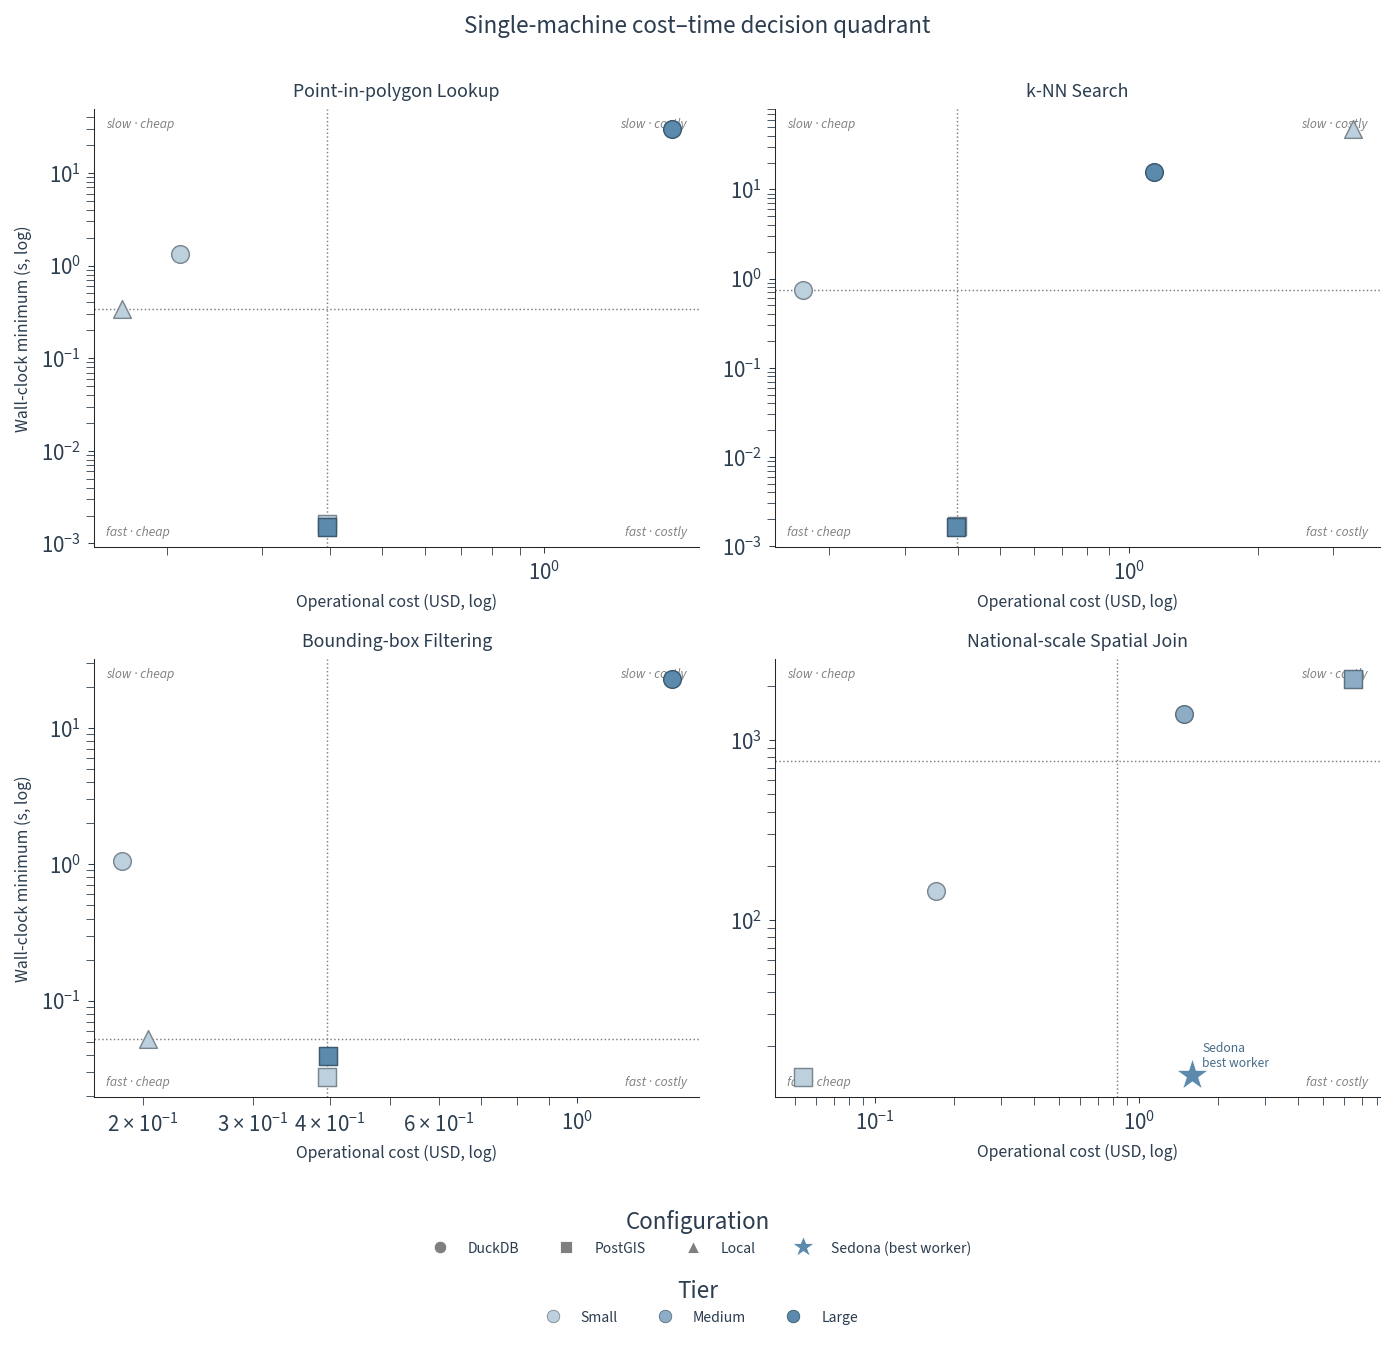

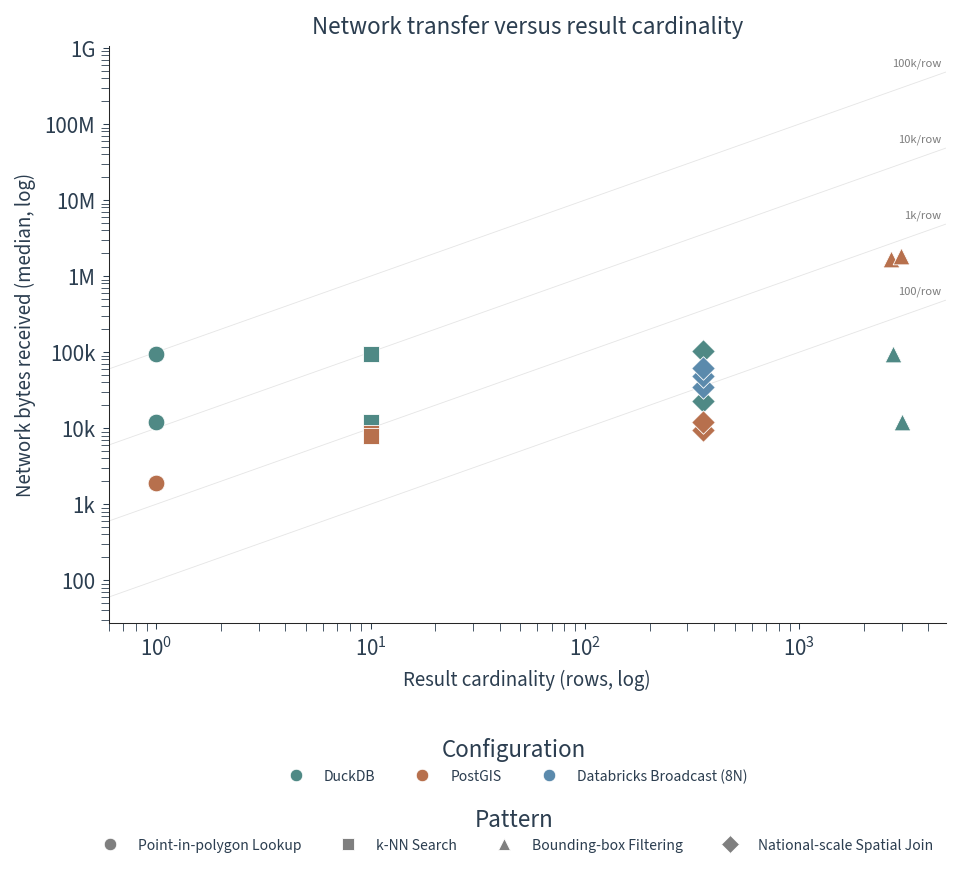

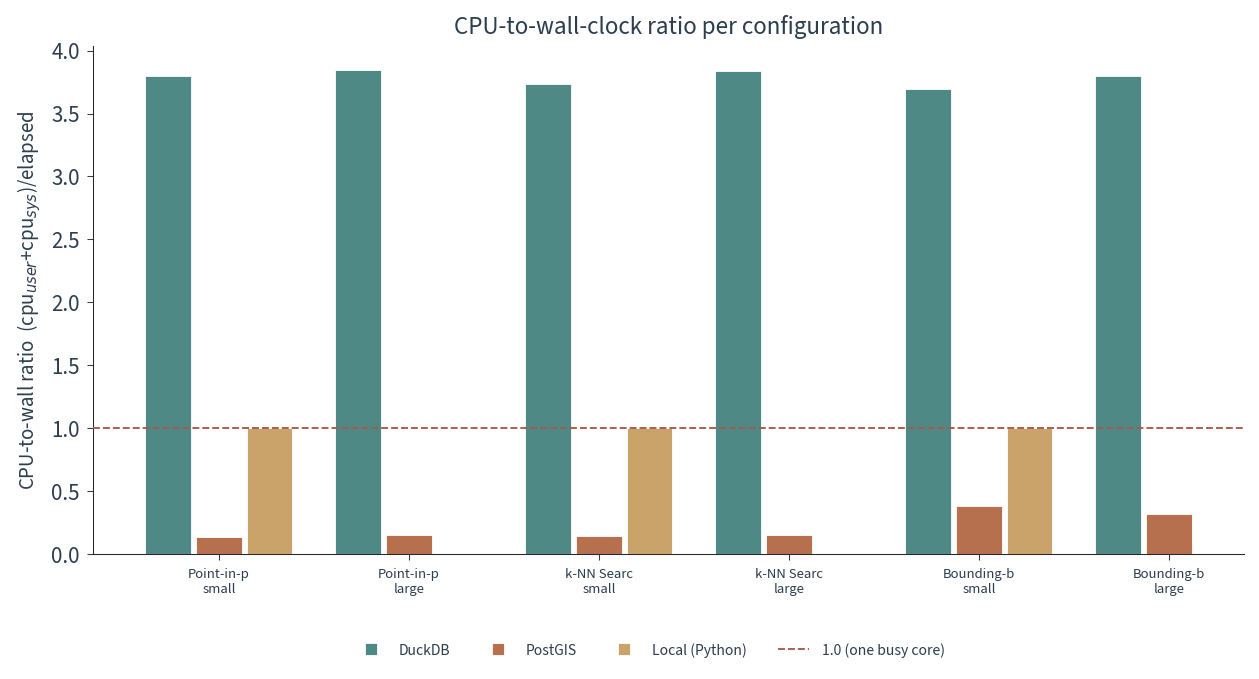

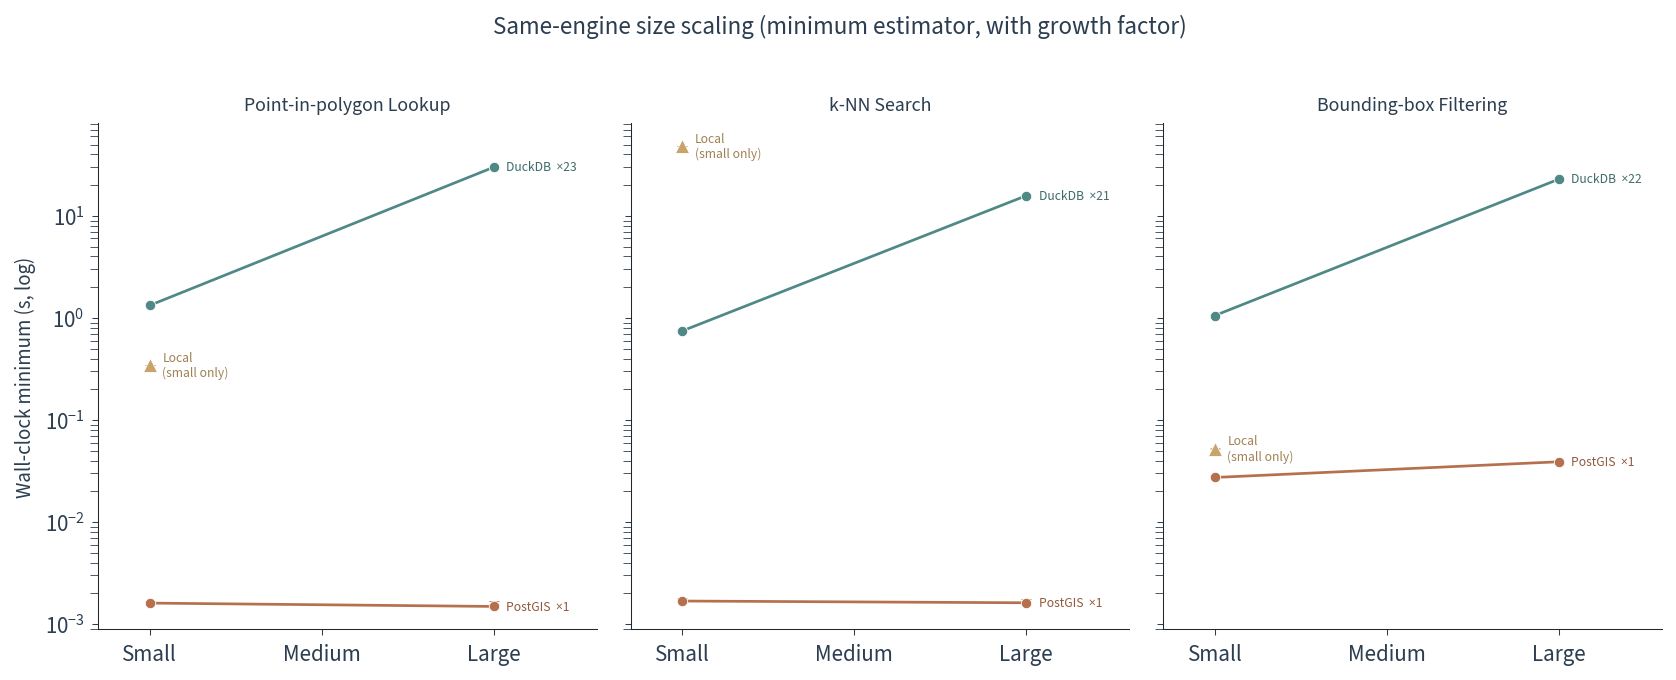

PosixPath('figures/09-size-scaling-slope.png')

In [3]:
# --- New RQ1 results + appendix figures (thesis_figures.fig_*) ---
ALLW = RQ1_W + ["national-scale-spatial-join"]
ALLT = ["small", "medium", "large"]
tf.fig_bytes_directional(successful, RQ1_W, RQ1_C, TIERS, style, FIG / "06-single-machine-bytes-directional.png")
tf.fig_cost_time_quadrant(cost_summary, successful, ALLW, RQ1_C, ALLT, style, FIG / "06-single-machine-cost-time-quadrant.png")
tf.fig_bytes_vs_cardinality(successful, ["duckdb", "postgis", "databricks-broadcast-8-nodes"], style, FIG / "06-bytes-vs-cardinality.png")
tf.fig_cpu_wall_ratio(successful, RQ1_W, RQ1_C, TIERS, style, FIG / "09-cpu-wall-ratio.png")
tf.fig_size_scaling_slope(successful, RQ1_W, RQ1_C, style, FIG / "09-size-scaling-slope.png")